# 01. EDA

##  Importamos Librerias

In [178]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from rapidfuzz import process, fuzz
from collections import defaultdict
from scipy.stats import mode
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import shapiro, skew, kurtosis
import os







## Carga del Dataset

In [ ]:
dit_quejas.head(20)

<>:1: SyntaxWarning:

invalid escape sequence '\d'

<>:1: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\Jon\AppData\Local\Temp\ipykernel_10808\1576858091.py:1: SyntaxWarning:

invalid escape sequence '\d'



,Unnamed: 0,Complaint ID,Product,Sub-product,Issue,Sub-issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?
0,0,1291006,Debt collection,NaN,Communication tactics,Frequent or repeated calls,TX,76119.0,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,NaN
1,1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,Debt is not mine,TX,77479.0,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,NaN
2,2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",NaN,MA,2127.0,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes
3,3,1291615,Credit card,NaN,Other,NaN,CA,92592.0,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,NaN
4,4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,Debt resulted from identity theft,NaN,43068.0,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,NaN
5,5,1291176,Debt collection,Payday loan,Communication tactics,Called after sent written cease of comm,OH,43068.0,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,NaN
6,6,1288848,Consumer loan,Installment loan,Managing the loan or lease,NaN,OH,44241.0,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes
7,7,1288788,Debt collection,Payday loan,Communication tactics,Called after sent written cease of comm,CA,95124.0,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,NaN
8,8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt was paid,NJ,7067.0,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,NaN
9,9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,Threatened arrest/jail if do not pay,TX,77433.0,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes


A continuación se presentan las primeras  entradas del dataset a trabajar, parece corresponder a quejas presentadas por consumidores ante la Oficina de Protección Financiera del Consumidor (CFPB). Esta muestra inicial nos permite familiarizarnos con la estructura del dataset. El dataset está compuesto por registros de quejas individuales presentadas por consumidores, donde cada fila representa una queja distinta. Las columnas incluidas ofrecen información detallada sobre diversos aspectos del conflicto: el tipo de producto financiero implicado (a través de las variables 'Product' y 'Sub-product'), la naturaleza del problema reportado ('Issue' y 'Sub-issue'), así como datos geográficos del consumidor ('State' y 'ZIP code'). También se recogen las fechas relevantes del proceso ('Date received' y 'Date sent to company'), la empresa implicada ('Company'), el tipo de respuesta proporcionada por esta ('Company response'). Tambien nos informa si dicha respuesta se emitió dentro del plazo establecido (Timely response?) y si el consumidor decidió disputar la resolución (Consumer disputed?). Además, se observa la presencia de una columna adicional denominada Unnamed: 0, que parece corresponder a un índice redundante generado automáticamente durante la importación del archivo, por lo que vamos a eliminarla en la fase de limpieza del dataset.



## Limpieza de Datos

### Eliminacion valores faltantes

In [180]:
dt_quejas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28156 entries, 0 to 28155
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            28156 non-null  int64  
 1   Complaint ID          28156 non-null  int64  
 2   Product               28156 non-null  object 
 3   Sub-product           17582 non-null  object 
 4   Issue                 28154 non-null  object 
 5   Sub-issue             13211 non-null  object 
 6   State                 27735 non-null  object 
 7   ZIP code              27876 non-null  float64
 8   Date received         28156 non-null  object 
 9   Date sent to company  28156 non-null  object 
 10  Company               28156 non-null  object 
 11  Company response      28156 non-null  object 
 12  Timely response?      28156 non-null  object 
 13  Consumer disputed?    6006 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 3.0+ MB


Podemos observar que el conjunto de datos contiene 28.156 registros y 14 columnas. Además, podemos identificar varias columnas con valores nulos, especialmente 'Sub-product', 'Sub-issue' y 'Consumer disputed?', lo que sugiere la necesidad de realizar un tratamiento adecuado de los datos faltantes antes del análisis. También destaca la presencia de la columna 'Unnamed: 0', que actúa como un índice redundante y que vamos a eliminar ya que no supone pérdida de información. Por último, la mayoría de las variables son de tipo object, incluyendo las fechas, por lo que será necesario convertirlas al tipo de dato datetime para su análisis temporal.



In [181]:
dt_quejas_corr = dt_quejas.drop(columns=['Unnamed: 0'])

dt_quejas_corr['Consumer disputed?'] = dt_quejas_corr.apply(
    lambda row: (
        'No' if pd.isna(row['Consumer disputed?']) and 'Closed' in row['Company response']
        else 'Pending' if pd.isna(row['Consumer disputed?']) and (
            row['Company response'] == 'In progress' or row['Company response'] == 'Untimely response'
        )
        else row['Consumer disputed?']
    ),
    axis=1
)

dt_quejas_corr.head(50)



,Complaint ID,Product,Sub-product,Issue,Sub-issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?
0,1291006,Debt collection,NaN,Communication tactics,Frequent or repeated calls,TX,76119.0,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,Debt is not mine,TX,77479.0,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",NaN,MA,2127.0,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes
3,1291615,Credit card,NaN,Other,NaN,CA,92592.0,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,Debt resulted from identity theft,NaN,43068.0,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending
5,1291176,Debt collection,Payday loan,Communication tactics,Called after sent written cease of comm,OH,43068.0,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,NaN,OH,44241.0,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes
7,1288788,Debt collection,Payday loan,Communication tactics,Called after sent written cease of comm,CA,95124.0,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt was paid,NJ,7067.0,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,Threatened arrest/jail if do not pay,TX,77433.0,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes


Una vez explorada la estructura general del dataset, el siguiente paso ha sido aplicar una limpieza básica para facilitar el análisis posterior. En primer lugar, se ha eliminado la columna 'Unnamed: 0', que correspondía a un índice redundante generado automáticamente al importar el archivo CSV. 

A continuación, se ha abordado el tratamiento de los valores nulos en la columna 'Consumer disputed?', que indica si el consumidor disputó o no la respuesta ofrecida por la empresa. Esta variable presentaba una cantidad significativa de valores ausentes. Para resolverlo, se aplicó una lógica basada en el contenido de la columna 'Company response'. Cuando la queja aparecía como cerrada y no se disponía de información sobre una disputa, se asumió que el consumidor no la había disputado y se asignó el valor 'No'. En los casos en los que la queja seguía en curso ('In progress') o la empresa no había respondido dentro del plazo estipulado ('Untimely response'), se interpretó que el caso seguía abierto o inconcluso, y se asignó el valor 'Pending'. De esta forma, se eliminaron los valores nulos respetando la lógica del proceso de resolución y evitando asumir resultados cerrados en situaciones no resueltas.

### Limpieza Columnas "State" y "Zip-Code"

Durante la exploración inicial del dataset, se identificaron valores ausentes tanto en la columna 'ZIP code' como en 'State'. Estas dos variables están relacionadas, por lo que es posible aprovechar una para inferir la otra y reducir la cantidad de datos faltantes.

In [182]:
zip_estados = {
    "AL": (35004, 36925),
    "AK": (99501, 99950),
    "AZ": (85001, 86556),
    "AR": (71601, 72959),
    "CA": (90001, 96162),
    "CO": (80001, 81658),
    "CT": (6001, 6928),
    "DE": (19701, 19980),
    "FL": (32003, 34997),
    "GA": (30002, 39901),
    "HI": (96701, 96898),
    "ID": (83201, 83877),
    "IL": (60001, 62999),
    "IN": (46001, 47997),
    "IA": (50001, 52809),
    "KS": (66002, 67954),
    "KY": (40003, 42788),
    "LA": (70001, 71497),
    "ME": (3901, 4992),
    "MD": (20588, 21930),
    "MA": (1001, 5544),
    "MI": (48001, 49971),
    "MN": (55001, 56763),
    "MS": (38601, 39776),
    "MO": (63001, 65899),
    "MT": (59001, 59937),
    "NE": (68001, 69367),
    "NV": (88901, 89883),
    "NH": (3031, 3897),
    "NJ": (7001, 8989),
    "NM": (87001, 88439),
    "NY": (501, 14925),
    "NC": (27006, 28909),
    "ND": (58001, 58856),
    "OH": (43001, 45999),
    "OK": (73001, 74966),
    "OR": (97001, 97920),
    "PA": (15001, 19640),
    "RI": (2801, 2940),
    "SC": (29001, 29945),
    "SD": (57001, 57799),
    "TN": (37010, 38589),
    "TX": (73301, 88595),
    "UT": (84001, 84791),
    "VT": (5001, 5907),
    "VA": (20101, 24658),
    "WA": (98001, 99403),
    "WV": (24701, 26886),
    "WI": (53001, 54990),
    "WY": (82001, 83414),
    "AS": (96799, 96799),   
    "MP": (96950, 96952),   
    "DC": (20001, 56972),   
    "PR": (601, 988),       
    "GU": (96910, 96932),   
    "VI": (801, 851)        
}

def infer_state_from_zip(zip_str: str) -> str:
    """Devuelve el estado a partir de un ZIP (string). Si no es válido, 'Unknown'."""
    if pd.isna(zip_str):
        return "Unknown"
    s = str(zip_str).strip()
    # Quita sufijos tipo '.0' y rellena con ceros a la izquierda si es numérico
    if s.endswith('.0'):
        s = s[:-2]
    if not s.isdigit():
        return "Unknown"
    try:
        z = int(s)
    except Exception:
        return "Unknown"
    for st, (lo, hi) in zip_estados.items():
        if lo <= z <= hi:
            return st
    return "Unknown"

min_zip_por_estado = {st: rng[0] for st, rng in zip_estados.items()}

dt_quejas_corr['State'] = (
    dt_quejas_corr['State']
    .astype(str)
    .str.strip()
    .replace({'nan': np.nan, 'None': np.nan, '': np.nan, 'Unknown': np.nan})
    .str.upper()
)

zip_raw = (
    dt_quejas_corr['ZIP code']
    .astype(str)
    .str.strip()
    .replace({'nan': np.nan, 'None': np.nan, 'Unknown': np.nan, '': np.nan})
)

zip_num = pd.to_numeric(zip_raw.str.replace('.0', '', regex=False), errors='coerce')

mask_state_na_zip_ok = dt_quejas_corr['State'].isna() & zip_num.notna()
dt_quejas_corr.loc[mask_state_na_zip_ok, 'State'] = (
    zip_raw[mask_state_na_zip_ok].apply(infer_state_from_zip)
)

dt_quejas_corr['State'] = dt_quejas_corr['State'].replace({'Unknown': np.nan})

# --- 3) Rellena ZIP a partir de State (mínimo ZIP del rango), solo donde ZIP falta ---
mask_zip_na_state_ok = zip_num.isna() & dt_quejas_corr['State'].notna()

# Imputa el ZIP como número entero "nullable" (Int64) sin pasar por string
zip_imputados = (
    dt_quejas_corr.loc[mask_zip_na_state_ok, 'State']
    .map(min_zip_por_estado)        # puede devolver NaN si el estado no está en el dict
)

dt_quejas_corr.loc[mask_zip_na_state_ok, 'ZIP code'] = zip_imputados

# --- 4) Formatea ZIP como string de 5 dígitos donde sea numérico; deja NaN si no ---
# Convierte a numérico con coerción (deja NaN cuando no sea interpretable)
zip_num2 = pd.to_numeric(dt_quejas_corr['ZIP code'], errors='coerce')

# Escribe sólo en las posiciones válidas (evita tocar los NaN)
mask_zip_ok = zip_num2.notna()
dt_quejas_corr.loc[mask_zip_ok, 'ZIP code'] = (
    zip_num2[mask_zip_ok].astype(int).astype(str).str.zfill(5)
)

# Opcional: para reporting, cuenta cuántos se imputaron en cada paso
imputados_state = mask_state_na_zip_ok.sum()
imputados_zip = mask_zip_na_state_ok.sum()
print(f"State imputados desde ZIP: {imputados_state}")
print(f"ZIP imputados desde State (mínimo del rango): {imputados_zip}")

# --- 5) Como último toque, si aún quedan State NaN y ZIP válido, intenta otra vez ---
mask_state_na_zip_ok2 = dt_quejas_corr['State'].isna() & dt_quejas_corr['ZIP code'].notna()
dt_quejas_corr.loc[mask_state_na_zip_ok2, 'State'] = (
    dt_quejas_corr.loc[mask_state_na_zip_ok2, 'ZIP code'].apply(infer_state_from_zip)
)
# Y si quedan inválidos, etiquétalos como 'Unknown' (o déjalos NaN si prefieres)
dt_quejas_corr['State'] = dt_quejas_corr['State'].fillna('Unknown')

# Info final
print(dt_quejas_corr[['State','ZIP code']].info())

State imputados desde ZIP: 267
ZIP imputados desde State (mínimo del rango): 126
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28156 entries, 0 to 28155
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   State     28156 non-null  object
 1   ZIP code  28002 non-null  object
dtypes: object(2)
memory usage: 440.1+ KB
None


C:\Users\Jon\AppData\Local\Temp\ipykernel_10808\1081565447.py:122: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['76119' '77479' '02127' ... '55105' '92509' '45068']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



In [183]:
dt_quejas_corr['State'].unique()

array(['TX', 'MA', 'CA', 'OH', 'NJ', 'ND', 'RI', 'CO', 'UT', 'AL', 'PA',
       'NY', 'NC', 'GA', 'IL', 'WI', 'MI', 'FL', 'CT', 'OR', 'VA', 'WA',
       'TN', 'MD', 'IA', 'KY', 'LA', 'OK', 'NE', 'KS', 'MO', 'NH', 'IN',
       'DC', 'NV', 'ME', 'NM', 'SC', 'AZ', 'AP', 'MS', 'MN', 'ID', 'HI',
       'PR', 'Unknown', 'WV', 'WY', 'AK', 'VI', 'MT', 'DE', 'AR', 'AE',
       'SD', 'GU', 'VT', 'MH', 'PW', 'AS'], dtype=object)

In [184]:
dt_quejas_corr['ZIP code'].isna

<bound method Series.isna of 0        76119
1        77479
2        02127
3        92592
4        43068
         ...  
28151    75201
28152    30043
28153    55105
28154    92509
28155    45068
Name: ZIP code, Length: 28156, dtype: object>

En primer lugar, se utilizó el código postal ('ZIP code') para inferir el estado ('State') cuando este último estaba ausente. Para ello, se definió una función auxiliar que asigna un estado en función del rango al que pertenece el código ZIP, según los tramos oficiales definidos para cada estado de EE.UU. Esta operación se aplicó únicamente a aquellas filas en las que 'State' era nulo, preservando el valor original en el resto de los casos.

In [185]:
def limpiar_zip(zip_value):
    try:
        if pd.isna(zip_value) or zip_value == 'Unknown':
            return 'Unknown'
        return str(int(float(zip_value))).zfill(5)
    except:
        return 'Unknown'

dt_quejas_corr['ZIP code'] = dt_quejas_corr['ZIP code'].apply(limpiar_zip)
dt_quejas_corr['ZIP code'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 28156 entries, 0 to 28155
Series name: ZIP code
Non-Null Count  Dtype 
--------------  ----- 
28156 non-null  object
dtypes: object(1)
memory usage: 220.1+ KB


Posteriormente, se procedió a realizar el proceso inverso: en aquellas entradas donde el 'ZIP code' estaba ausente, pero el 'State' estaba correctamente informado, se asignó un código postal representativo. Dado que no se necesita una localización precisa a nivel de ciudad o vecindario, se optó por utilizar el valor mínimo del rango oficial de códigos postales para cada estado.

### Limpieza columna 'Company'

In [186]:
dt_quejas_corr['Company'].unique()

array(['Premium Asset Services, LLC',
       'Accounts Receivable Consultants Inc.', 'RBS Citizens', ...,
       'Cohen McNeile & Pappas, PC', 'United Accounts, Inc.',
       'Allied International Credit Corporation'],
      shape=(1534,), dtype=object)

Como se puede observar el conjunto de datos contiene 1.534 empresas distintas que han sido objeto de al menos una queja. Esta cifra refleja una gran diversidad de entidades financieras implicadas, desde grandes corporaciones bancarias y agencias de crédito, hasta pequeñas empresas de cobro de deudas. La amplia variedad de compañías también sugiere que los conflictos con los consumidores no se limitan a unos pocos actores del mercado, sino que están distribuidos a lo largo de distintos servicios financieros y modelos de negocio.

In [187]:
quejas_por_compania = dt_quejas_corr['Company'].value_counts().reset_index()
quejas_por_compania.columns = ['Company', 'Complaint Count']

quejas_por_compania.head(50)

,Company,Complaint Count
0,Equifax,2049
1,Experian,1940
2,TransUnion,1525
3,Bank of America,1518
4,Wells Fargo,1430
5,JPMorgan Chase,1272
6,Citibank,1016
7,Ocwen,934
8,Nationstar Mortgage,749
9,Capital One,567


Si observamos la distribución de las quejas, se aprecia una alta concentración en un número muy reducido de compañías. De hecho, las 50 empresas con mayor número de reclamaciones acumulan una parte significativa del total. Este patrón nos sugiere una distribución fuertemente sesgada: unas pocas empresas grandes concentran miles de quejas, mientras que la mayoría de las compañías (más de 1.400) aparecen con una frecuencia muy baja

In [188]:
frecuencia = dt_quejas_corr['Company'].value_counts()
companias_frecuentes = frecuencia[frecuencia > 50].index.tolist()

dt_quejas_corr['Company_grouped_filtered'] = dt_quejas_corr['Company'].apply(
    lambda x: x if x in companias_frecuentes else 'Low Count Companies'
)

dt_quejas_corr['Company_grouped_filtered'].value_counts()


Company_grouped_filtered
Low Count Companies                       7118
Equifax                                   2049
Experian                                  1940
TransUnion                                1525
Bank of America                           1518
                                          ... 
The Huntington National Bank                55
ACE Cash Express Inc.                       53
Receivables Performance Management LLC      52
Dynamic Recovery Solutions, LLC             51
Shellpoint Partners, LLC                    51
Name: count, Length: 68, dtype: int64

Dado que la columna 'Company' contenía más de 1.500 valores únicos, se realizó una reducción de cardinalidad para facilitar el análisis. Para ello, primero se agruparon o normalizaron los nombres de las empresas en una nueva columna 'Company_grouped_filtered'. A continuación, se calculó la frecuencia de aparición de cada empresa y se identificaron aquellas que acumulan más de 50 quejas, ya que representan los actores más relevantes del conjunto de datos. Mediante filtrado las empresas con menor numero de quejas fueron agrupadas bajo la categoría 'Low Count Companies'. Este enfoque permite conservar el detalle sobre las compañías más problemáticas, al mismo tiempo que se simplifica el análisis y las visualizaciones al evitar la fragmentación en cientos de categorías con escasa representación individual.

### Columnas 'Product', 'Sub-product', 'Issue' y 'Sub-Issue'

In [189]:
dt_quejas_corr['Product'].unique()

array(['Debt collection', 'Mortgage', 'Credit card', 'Consumer loan',
       'Bank account or service', 'Payday loan', 'Credit reporting',
       'Money transfers', 'Student loan', 'Prepaid card',
       'Other financial service'], dtype=object)

Las categorias dentro de 'Product' presentan servicios como la recolección de deudas (Debt collection), hipotecas (Mortgage), tarjetas de crédito (Credit card), préstamos personales o de consumo (Consumer loan), cuentas bancarias (Bank account or service), préstamos de día de pago (Payday loan), informes de crédito (Credit reporting), transferencias de dinero (Money transfers), préstamos estudiantiles (Student loan), tarjetas prepago (Prepaid card) y otros servicios financieros (Other financial service). Cada una de estas etiquetas agrupa tipos similares de productos, facilitandonos el análisis de tendencias y patrones de quejas.

In [190]:
subproductos_por_producto = pd.crosstab(dt_quejas_corr['Sub-product'], dt_quejas_corr['Product'])
subproductos_por_producto = subproductos_por_producto.loc[(subproductos_por_producto.sum(axis=1) > 0)]
display(subproductos_por_producto.sort_index())

Product,Bank account or service,Consumer loan,Debt collection,Money transfers,Mortgage,Other financial service,Prepaid card,Student loan
Sub-product,,,,,,,,
(CD) Certificate of deposit,99,0,0,0,0,0,0,0
Auto,0,0,164,0,0,0,0,0
Cashing a check without an account,22,0,0,0,0,0,0,0
Check cashing,0,0,0,0,0,16,0,0
Checking account,1693,0,0,0,0,0,0,0
Conventional adjustable mortgage (ARM),0,0,0,0,800,0,0,0
Conventional fixed mortgage,0,0,0,0,2446,0,0,0
Credit card,0,0,1447,0,0,0,0,0
Credit repair,0,0,0,0,0,6,0,0


Al analizar la tabla de relación entre Sub-product y Product, se observa que la mayoría de sub-productos están asociados a un único producto principal, lo que sugiere una relación predominantemente uno a uno. Por ejemplo, el sub-producto "Checking account" aparece únicamente bajo el producto "Bank account or service", mientras que "Auto" está registrado solo bajo "Debt collection", y "(CD) Certificate of deposit" únicamente bajo "Bank account or service".

Sin embargo, hay algunos sub-productos que pueden aparecer en más de una categoría de producto, aunque son casos menos frecuentes. Esta consistencia indica que los sub-productos suelen ser específicos de su producto padre, lo que facilita su análisis y posible imputación de valores faltantes

In [191]:
issue_counts_incl_nan = dt_quejas_corr['Issue'].fillna('Missing').value_counts()
subissue_counts_incl_nan = dt_quejas_corr['Sub-issue'].fillna('Missing').value_counts()

print(issue_counts_incl_nan)
print(subissue_counts_incl_nan)

Issue
Incorrect information on credit report      4170
Cont'd attempts collect debt not owed       3351
Loan modification,collection,foreclosure    3049
Loan servicing, payments, escrow account    2627
Disclosure verification of debt             1300
                                            ... 
Lost or stolen check                           2
Advertising, marketing or disclosures          2
Lender damaged or destroyed vehicle            2
Overdraft, savings or rewards features         1
Excessive fees                                 1
Name: count, Length: 90, dtype: int64
Sub-issue
Missing                                     14945
Debt is not mine                             2125
Account status                               1604
Information is not mine                      1307
Debt was paid                                 890
Not given enough info to verify debt          815
Frequent or repeated calls                    754
Account terms                                 484
Attempt

Para estas dos columnas, hay 89 categorías únicas en la columna 'Issue' y 46 subcategorías únicas en 'Sub-issue'. Unicamente 2 valores están vacíos en 'Issue', mientras que 14.945 valores faltan en 'Sub-issue', lo cual indica que en esta ultima existen valores nulos en mas 50% del dataset. Al parecer 'Sub-issue' es una ampliacion infromativa de la primera podemos prescindir de esta columna.

De la misma forma que hemos realizado anteriormente, dado que estas 3 columnas pueden presentar una correlacion, igual podemos imputarlas entre si para rellenar valores faltantes. Dado que es posible ciertos 'issues' se asocien unicamente a una categoria de producto, permitiendonos asi, completar dichos valores. 

In [192]:
dt_quejas_corr.drop(columns=['Sub-issue'], inplace=True)


combinaciones = (
    dt_quejas_corr
    .dropna(subset=['Issue'])
    .groupby(['Product', 'Sub-product'])['Issue']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

dt_quejas_corr = dt_quejas_corr.merge(
    combinaciones,
    on=['Product', 'Sub-product'],
    how='left',
    suffixes=('', '_imputed')
)

dt_quejas_corr['Issue'] = dt_quejas_corr['Issue'].fillna(dt_quejas_corr['Issue_imputed'])
dt_quejas_corr.drop(columns=['Issue_imputed'], inplace=True)

dt_quejas_corr['Issue'].info()


<class 'pandas.core.series.Series'>
RangeIndex: 28156 entries, 0 to 28155
Series name: Issue
Non-Null Count  Dtype 
--------------  ----- 
28156 non-null  object
dtypes: object(1)
memory usage: 220.1+ KB


Se ha imputado la columna 'Issue' en base a las combinaciones de 'Product' y 'Sub-product', partiendo de la idea de que ciertos subproductos suelen estar asociados a un único tipo de incidencia. Para ello, se calculó la moda de 'Issue' en cada combinación 'Product'-'Sub-product' y se utilizó esta información para rellenar los valores faltantes. Este método permite mantener la coherencia interna del dataset aprovechando relaciones existentes, mejorando así la calidad de los datos de cara al modelado.

In [193]:
dicc_prod_issue_to_subprod = (
    dt_quejas_corr.dropna(subset=['Sub-product'])
    .groupby(['Product', 'Issue'])['Sub-product']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .to_dict()
)

def imputar_subproducto(row):
    if pd.isna(row['Sub-product']):
        return dicc_prod_issue_to_subprod.get((row['Product'], row['Issue']), np.nan)
    return row['Sub-product']

dt_quejas_corr['Sub-product'] = dt_quejas_corr.apply(imputar_subproducto, axis=1)
dt_quejas_corr['Sub-product'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 28156 entries, 0 to 28155
Series name: Sub-product
Non-Null Count  Dtype 
--------------  ----- 
19261 non-null  object
dtypes: object(1)
memory usage: 220.1+ KB


Para imputar los valores faltantes en la columna Sub-product, se aprovechó la relación existente entre las variables Product e Issue. Se construyó un diccionario que, para cada combinación de producto e incidencia, asigna la subcategoría más frecuente (la moda). Esto se basa en la hipótesis de que ciertos tipos de incidencias suelen estar asociadas a un único subproducto.

A continuación, se aplicó una función fila a fila para rellenar los valores nulos de Sub-product, utilizando el diccionario creado. En caso de no encontrar una correspondencia, el valor se mantiene como faltante.

In [194]:
dt_quejas_corr['Sub-product'] = dt_quejas_corr['Sub-product'].fillna('Unknown')
print(dt_quejas_corr['Sub-product'].value_counts(dropna=False).head())
dt_quejas_corr['Sub-product'].info()

Sub-product
Unknown                             8895
Other (phone, health club, etc.)    3412
Conventional fixed mortgage         2446
Credit card                         1987
Other mortgage                      1954
Name: count, dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 28156 entries, 0 to 28155
Series name: Sub-product
Non-Null Count  Dtype 
--------------  ----- 
28156 non-null  object
dtypes: object(1)
memory usage: 220.1+ KB


Para finalizar la limpieza de la variable Sub-product, se decidió imputar los valores faltantes con la categoría "Unknown", manteniendo así la consistencia del tipo de dato y facilitando el posterior tratamiento durante la fase de modelado. Esta imputación se justifica en que no todos los valores pueden ser inferidos de forma confiable a partir de otras columnas, y es preferible agrupar los casos con información incompleta bajo una categoría explícita.

Tras la imputación, la columna quedó completamente libre de valores nulos, con 8.895 registros etiquetados como "Unknown". Esto representa una proporción significativa del total, por lo que se tendrá en cuenta su posible impacto durante el análisis exploratorio y la creación del modelo predictivo.

### Columna 'Date recieved' y 'Date Sent to company'

Para las columnas con fechas, Calcular el tiempo transcurrido entre ambas fechas puede proporcionarnos una nueva variable numérica (en días) que sintetiza de forma clara la relación temporal entre ellas. Esto nos aporta una mayor simplicidad a la hora de trabajar con el modelo, una reducción de la dimensionalidad y una representación de la información más relevante y fácil de interpretar.

In [195]:
dt_quejas_corr['Date received'] = pd.to_datetime(dt_quejas_corr['Date received'])
dt_quejas_corr['Date sent to company'] = pd.to_datetime(dt_quejas_corr['Date sent to company'])

dt_quejas_corr['Difference in days'] = (dt_quejas_corr['Date sent to company'] - dt_quejas_corr['Date received']).dt.days

print(dt_quejas_corr['Difference in days'].unique())
dt_quejas_corr['Difference in days'].info()


[ 0  1  2  3  4  6  5  7  8  9 11 10 15 12 16 13 17 14 21 20 18 19 22 28
 23 24 29 26 25 31 27 30 35 32 33 36 39 34 37 38 43 42 41 46 45 48 40 61
 47 44 59 64 57 60 53 52 55]
<class 'pandas.core.series.Series'>
RangeIndex: 28156 entries, 0 to 28155
Series name: Difference in days
Non-Null Count  Dtype
--------------  -----
28156 non-null  int64
dtypes: int64(1)
memory usage: 220.1 KB


In [196]:
dt_quejas_corr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28156 entries, 0 to 28155
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Complaint ID              28156 non-null  int64         
 1   Product                   28156 non-null  object        
 2   Sub-product               28156 non-null  object        
 3   Issue                     28156 non-null  object        
 4   State                     28156 non-null  object        
 5   ZIP code                  28156 non-null  object        
 6   Date received             28156 non-null  datetime64[ns]
 7   Date sent to company      28156 non-null  datetime64[ns]
 8   Company                   28156 non-null  object        
 9   Company response          28156 non-null  object        
 10  Timely response?          28156 non-null  object        
 11  Consumer disputed?        28156 non-null  object        
 12  Company_grouped_fi

In [197]:
dt_quejas_corr.head()

,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0


# Analisis Descriptivo

C:\Users\Jon\AppData\Local\Temp\ipykernel_10808\1422860172.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




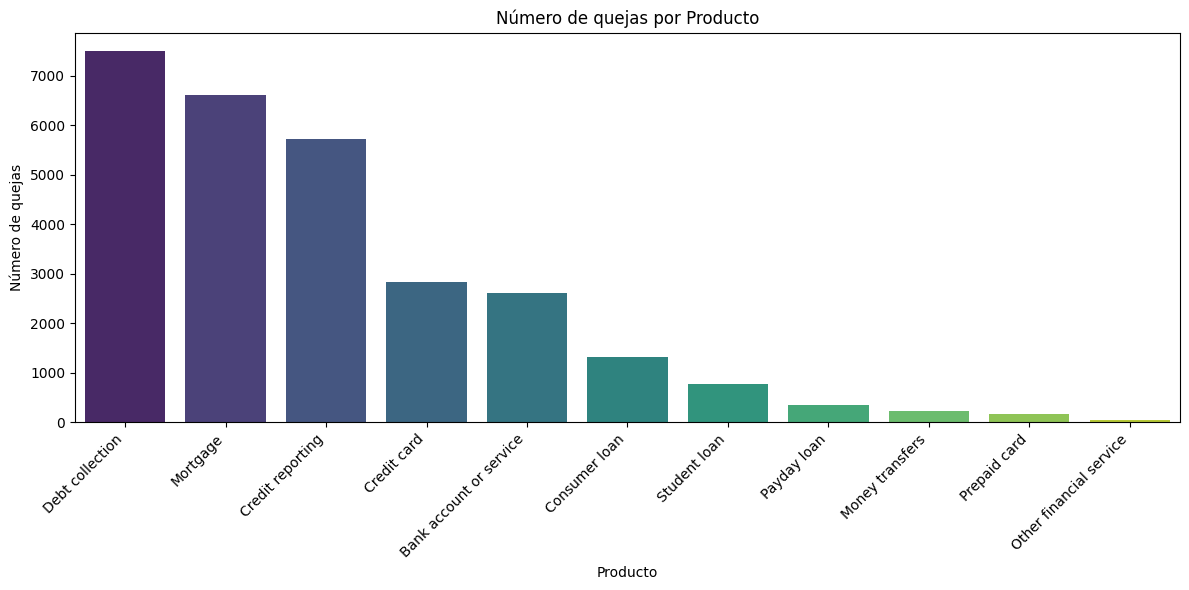

In [198]:
quejas_por_producto = dt_quejas_corr['Product'].value_counts().reset_index()
quejas_por_producto.columns = ['Product', 'Count']

plt.figure(figsize=(12,6))
sns.barplot(data=quejas_por_producto, x='Product', y='Count', palette='viridis')
plt.title('Número de quejas por Producto')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Número de quejas')
plt.xlabel('Producto')
plt.tight_layout()
plt.show()

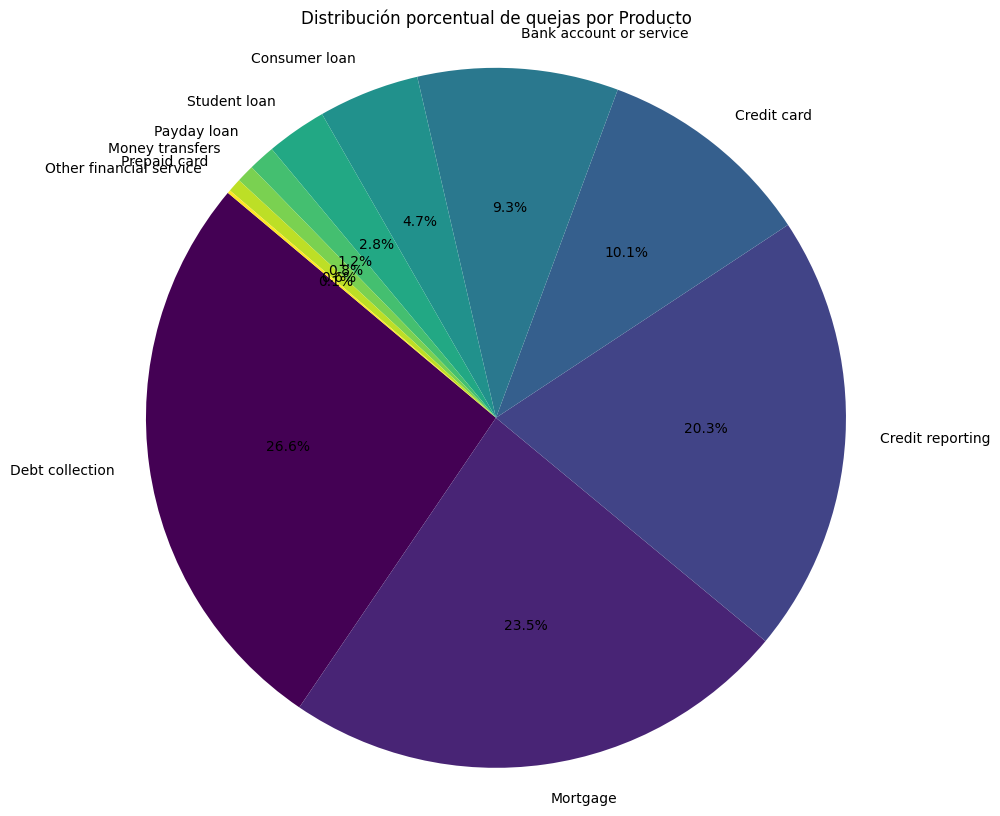

In [199]:
plt.figure(figsize=(12,10))
plt.pie(
    quejas_por_producto['Count'],
    labels=quejas_por_producto['Product'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.viridis(np.linspace(0, 1, len(quejas_por_producto)))
)
plt.title('Distribución porcentual de quejas por Producto')
plt.axis('equal')
plt.show()

Se observa que los tres productos financieros con mayor volumen de quejas son "Debt collection" (Cobro de deudas), con más del 26% del total, seguido de "Mortgage" (Hipotecas) con un 23,5% y "Credit reporting" (Informes crediticios) con un 20,3%. Esta concentración de reclamaciones en dichas categorías podría reflejar tanto un elevado volumen de uso por parte de los consumidores como problemáticas frecuentes, como prácticas agresivas de cobro, errores en la gestión de hipotecas o inexactitudes en los informes de crédito.

En segundo plano se sitúan productos como "Credit card" (10,1%) y "Bank account or service" (9,3%), asociados a conflictos con pagos, comisiones o atención al cliente. Más abajo aparecen "Consumer loan" (4,7%) y "Student loan" (2,8%), probablemente con menor presencia por su menor cuota de mercado o complejidad operativa.

Por último, productos como "Payday loan", "Money transfers", "Prepaid card" y "Other financial service" acumulan conjuntamente menos del 3% de las quejas, lo que puede estar relacionado con su menor uso generalizado o con una operativa menos conflictiva. En conjunto, el análisis permite identificar los sectores con mayor percepción de riesgo o insatisfacción por parte de los consumidores.

In [200]:
fig = px.sunburst(
    dt_quejas_corr,
    path=['Product', 'Sub-product'],
    title='Relación jerárquica entre Producto y Sub-producto',
    width=1500,
    height=800
)

fig.show()

En el caso del siguiente grafico tenemos una representacion jerárquica de la relación entre los productos financieros y sus respectivos sub-productos, permitiendo visualizar la distribución interna de las quejas dentro de cada categoría principal. Su estructura facilita identificar tanto la especificidad de ciertas categorías como la presencia de datos faltantes o poco informativos.

Por ejemplo, en la categoría Mortgage, se observa una buena clasificación en sub-productos como "Conventional fixed mortgage", "FHA mortgage" o "Other mortgage". Esto indica que los usuarios suelen especificar claramente el tipo de hipoteca, lo que permite un análisis más preciso. También es una buena señal de calidad de datos dentro de esta categoría.

En cambio, en Credit reporting y Credit card, aparece un gran bloque marcado como "Unknown". Esto significa que, aunque se ha identificado el producto principal, no se ha sub-producto y como dato faltante. Esto puede deberse a que los usuarios no tienen claro qué tipo de tarjeta o informe están usando, o que el formulario de quejas no les obliga a concretarlo. Desde el punto de vista del análisis, esto supone una pérdida de información y limita el nivel de detalle que podemos obtener.

Por otro lado, en Debt collection, hay bastante variedad en los sub-productos. Aparecen categorías como "Medical", "Credit card" o "Other (phone, health club, etc.)". Esto sugiere que los conflictos con cobranzas afectan a muchos tipos de deudas, y que el problema está más relacionado con las prácticas de recobro que con el tipo de producto original.

En categorías como Consumer loan, Student loan o Bank account or service, se ven menos quejas, pero la clasificación es más clara. Por ejemplo, "Vehicle loan" o "Checking account" aparecen bien definidos, lo que también puede facilitar su análisis posterior.



In [201]:
dt_quejas_corr['Issue'] = dt_quejas_corr['Issue'].fillna('Unknown')

fig = px.sunburst(
    dt_quejas_corr,
    path=['Product', 'Issue'],
    title='Relación jerárquica entre Producto e Issue',
    width=1500,
    height=900
)

fig.show()

El siguiente grafico nos muestra la relación jerárquica entre el tipo de producto financiero (Product) y el tipo de problema reportado por el consumidor (Issue). A través de esta visualización, podemos observar qué tipos de problemas son más comunes dentro de cada categoría de producto.

Por ejemplo, en el caso de Mortgage (hipotecas), vemos una gran concentración de quejas relacionadas con "Loan modification, collection, foreclosure" y "Loan servicing, payments, escrow account". Esto indica que los usuarios tienen muchas dificultades tanto con el pago y administración de sus hipotecas como con los procesos asociados a modificaciones de préstamo o ejecuciones hipotecarias. Desde el punto de vista analítico, esto sugiere que en esta categoría los issues están bien definidos y podrían ser predictivos.

En Debt collection (cobro de deudas), los issues están más diversificados, pero destacan "Cont’d attempts collect debt not owed", "Disclosure verification of debt" y "Communication tactics". Esto puede indicar un alto nivel de conflicto en esta categoría, con múltiples tipos de malas prácticas o errores. En modelos futuros, esta variedad puede requerir una agrupación de issues o una codificación más específica.

En el caso de Credit reporting (informes de crédito), el issue más predominante con diferencia es "Incorrect information on credit report", lo que refleja que la mayoría de los problemas reportados por los consumidores están relacionados con errores en los datos que figuran en su historial crediticio. Esta concentración tan clara puede ser útil si más adelante queremos reducir clases o identificar patrones.

Otros productos como Credit card, Consumer loan o Bank account or service presentan una mayor variedad de issues, pero en proporciones más pequeñas, lo que indica una distribución más dispersa. Esto puede suponer un reto para el modelado, ya que las clases podrían estar desbalanceadas o ser difíciles de predecir si no se agrupan adecuadamente.

C:\Users\Jon\AppData\Local\Temp\ipykernel_10808\4286806389.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




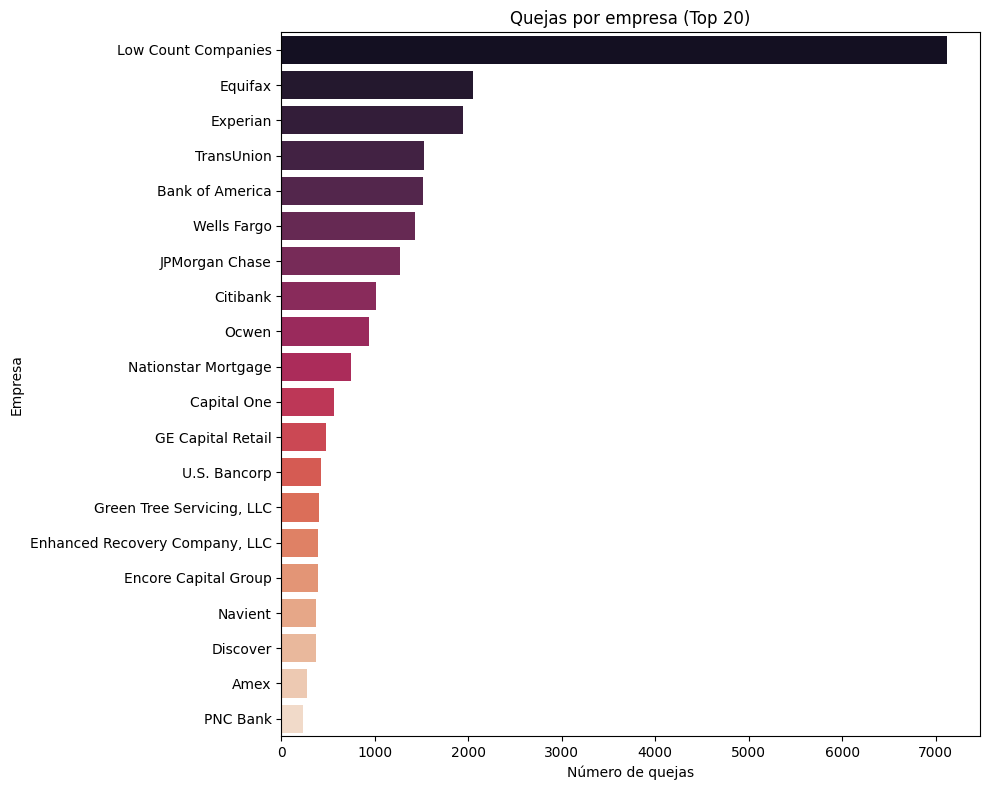

In [202]:
plt.figure(figsize=(10,8))
sns.countplot(data=dt_quejas_corr, y='Company_grouped_filtered', order=dt_quejas_corr['Company_grouped_filtered'].value_counts().head(20).index, palette='rocket')
plt.title("Quejas por empresa (Top 20)")
plt.xlabel("Número de quejas")
plt.ylabel("Empresa")
plt.tight_layout()
plt.show()

Se observa que, al analizar las compañías con mayor volumen de quejas, las principales protagonistas del gráfico son las tres grandes agencias de informes crediticios: Equifax, Experian y TransUnion, todas con más de 1.900 quejas cada una. Este dato refuerza lo visto en análisis anteriores, donde "Credit reporting" se posicionaba como uno de los productos con mayor número de reclamaciones. Le siguen de cerca los principales bancos comerciales de EE.UU., como Bank of America, Wells Fargo, JPMorgan Chase y Citibank, que también superan ampliamente el umbral de las 1.000 quejas, probablemente debido tanto a su elevada base de clientes como a problemáticas habituales relacionadas con hipotecas, cuentas o tarjetas.

Un aspecto interesante del gráfico es la categoría de "Low Count Companies", que agrupa a todas las empresas con 50 o menos quejas. A pesar de tratarse de entidades individuales con baja frecuencia de incidencias, al agruparlas suman más que cualquier compañía por separado, superando incluso las 7.000 quejas. Esto sugiere una larga cola de empresas pequeñas o menos conocidas que, si bien no destacan por sí solas, aportan significativamente al volumen total de reclamaciones.

Este análisis permite identificar de manera clara qué actores del sistema financiero acumulan una mayor percepción negativa por parte de los consumidores, información clave tanto para fines regulatorios como para estrategias de mejora empresarial o entrenamientos de modelos predictivos centrados en la detección de riesgo o disconformidad.

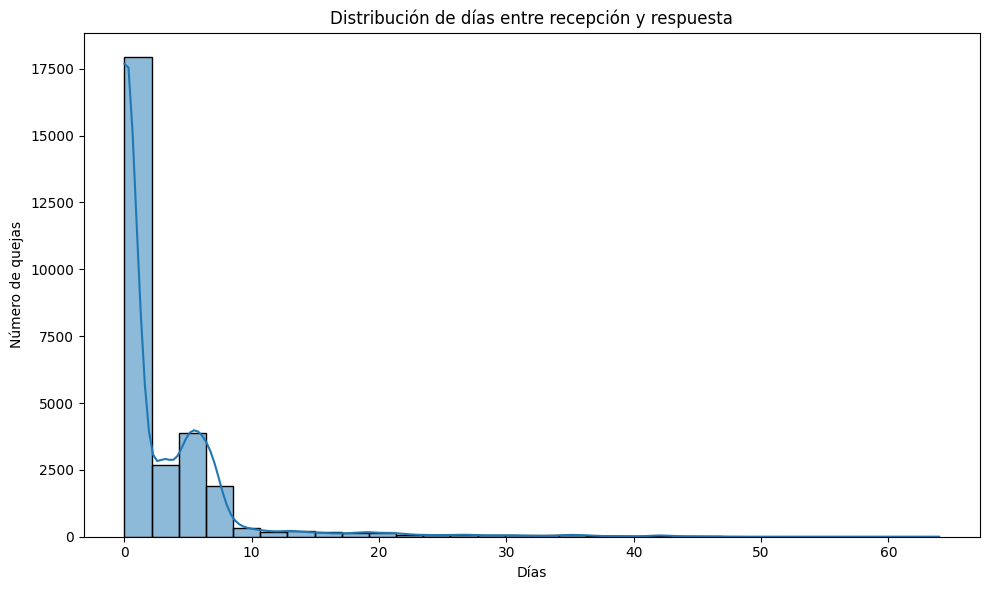

In [203]:
plt.figure(figsize=(10,6))
sns.histplot(dt_quejas_corr['Difference in days'], bins=30, kde=True)
plt.title("Distribución de días entre recepción y respuesta")
plt.xlabel("Días")
plt.ylabel("Número de quejas")
plt.tight_layout()
plt.show()

In [204]:
s = dt_quejas_corr['Difference in days']

descripcion = s.describe() 

stat, p_value = shapiro(s)
normalidad = 'Normal' if p_value > 0.05 else 'No normal'
asimetria = skew(s)
curt = kurtosis(s)  


q1 = descripcion['25%']
q2 = descripcion['50%'] 
q3 = descripcion['75%']
iqr = q3 - q1

tabla_estadistica = pd.DataFrame({
    'Estadístico': [
        'Media', 'Mediana', 'Desviación estándar',
        'Mínimo', 'Q1 (25%)', 'Q3 (75%)', 'IQR', 'Máximo',
        'Asimetría', 'Curtosis', 'Normalidad (Shapiro)'
    ],
    'Valor': [
        descripcion['mean'],
        descripcion['50%'],
        descripcion['std'],
        descripcion['min'],
        q1,
        q3,
        iqr,
        descripcion['max'],
        asimetria,
        curt,
        normalidad
    ]
})


tabla_estadistica['Valor'] = tabla_estadistica['Valor'].apply(
    lambda x: round(x, 4) if isinstance(x, (int, float, float)) else x
)

tabla_estadistica

c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 28156.



,Estadístico,Valor
0,Media,2.9595
1,Mediana,1.0
2,Desviación estándar,5.444
3,Mínimo,0.0
4,Q1 (25%),0.0
5,Q3 (75%),5.0
6,IQR,5.0
7,Máximo,64.0
8,Asimetría,3.9567
9,Curtosis,21.2218


In [ ]:
resultados = []

for producto, grupo in dt_quejas_corr.groupby("Product"):
    s = grupo["Difference in days"].dropna()
    if len(s) < 3:
        continue
    
    descripcion = s.describe()
    q1 = descripcion['25%']
    q2 = descripcion['50%']
    q3 = descripcion['75%']
    iqr = q3 - q1

    try:
        stat, p_value = shapiro(s.sample(5000, random_state=42)) if len(s) > 5000 else shapiro(s)
        normalidad = 'Normal' if p_value > 0.05 else 'No normal'
    except:
        normalidad = 'Error'

    resultados.append({
        "Producto": producto,
        "Media": descripcion['mean'],
        "Mediana": q2,
        "Desviación estándar": descripcion['std'],
        "Mínimo": descripcion['min'],
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "IQR": iqr,
        "Máximo": descripcion['max'],
        "Asimetría": skew(s),
        "Curtosis": kurtosis(s),
        "Normalidad (Shapiro)": normalidad
    })

tabla_productos = pd.DataFrame(resultados)
for col in tabla_productos.columns:
    if tabla_productos[col].dtype in ["float64", "int64"]:
        tabla_productos[col] = tabla_productos[col].round(4)

tabla_productos

,Producto,Media,Mediana,Desviación estándar,Mínimo,Q1 (25%),Q3 (75%),IQR,Máximo,Asimetría,Curtosis,Normalidad (Shapiro)
0,Bank account or service,2.3392,1.0,3.2130,0.0,0.0,4.00,4.00,42.0,4.4719,40.8874,No normal
1,Consumer loan,3.3379,2.0,4.9882,0.0,0.0,5.00,5.00,45.0,3.9012,21.5922,No normal
2,Credit card,2.2686,1.0,3.7411,0.0,0.0,4.00,4.00,61.0,4.7380,43.6915,No normal
3,Credit reporting,4.6089,0.0,8.4757,0.0,0.0,6.00,6.00,64.0,2.5268,6.7475,No normal
4,Debt collection,2.6924,1.0,4.9812,0.0,0.0,5.00,5.00,61.0,4.2693,26.7470,No normal
5,Money transfers,1.6509,1.0,2.7561,0.0,0.0,2.25,2.25,24.0,3.3538,19.0637,No normal
6,Mortgage,2.3466,1.0,3.7088,0.0,0.0,5.00,5.00,55.0,4.5385,38.9089,No normal
7,Other financial service,6.9750,6.0,5.5493,0.0,5.0,7.00,2.00,27.0,2.1498,5.0338,No normal
8,Payday loan,3.7011,2.0,5.0132,0.0,0.0,6.00,6.00,38.0,2.6973,11.1535,No normal
9,Prepaid card,5.0857,5.0,3.7245,0.0,3.0,6.50,3.50,35.0,3.6465,24.5975,No normal


El gráfico muestra la distribución de los días transcurridos entre la recepción de una queja y la respuesta por parte de la empresa. Se observa una distribución altamente asimétrica hacia la derecha, con un gran pico en los días 0 y 1, lo que indica que la mayoría de las quejas son respondidas de forma muy rápida. A medida que aumenta el número de días, la frecuencia de respuesta disminuye drásticamente, aunque se registran algunos casos atípicos con demoras superiores a los 30 días.

Las estadísticas descriptivas refuerzan esta observación: la media es de aproximadamente 2,96 días, mientras que la mediana es de 1 día, lo que refleja la influencia de valores extremos en la media. La desviación estándar de 5,44 y una asimetría de 3,96 indican una fuerte dispersión y sesgo hacia la derecha. Además, la curtosis de 21,22 revela una distribución con colas largas y un pico muy pronunciado, con muchos casos concentrados en tiempos de respuesta muy cortos.

El test de normalidad de Shapiro-Wilk confirma que la variable no sigue una distribución normal, lo que sugiere que, para su uso en modelos de machine learning, podría ser útil aplicar una transformación (como logarítmica) para reducir la asimetría si el algoritmo lo requiere.

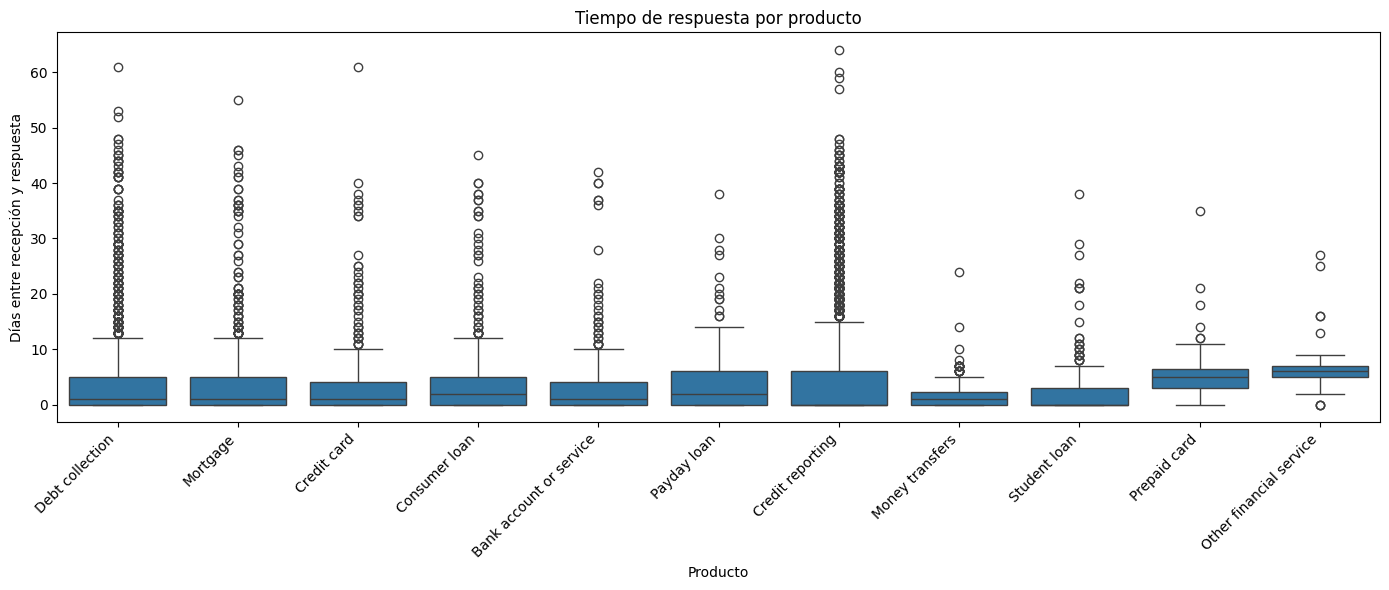

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=dt_quejas_corr,
    x="Product",
    y="Difference in days",
    showfliers=True   # Muestra outliers
)

plt.xticks(rotation=45, ha="right")
plt.title("Tiempo de respuesta por producto")
plt.xlabel("Producto")
plt.ylabel("Días entre recepción y respuesta")
plt.tight_layout()
plt.show()

In [205]:
import plotly.express as px

quejas_por_estado = dt_quejas_corr['State'].value_counts().reset_index()
quejas_por_estado.columns = ['state', 'count']
quejas_por_estado = quejas_por_estado[quejas_por_estado['state'].apply(lambda x: isinstance(x, str) and len(x) == 2)]

fig = px.choropleth(
    quejas_por_estado,
    locations='state',         
    locationmode='USA-states', 
    color='count',             
    color_continuous_scale="Viridis",
    scope="usa",               
    labels={'count':'Número de quejas'},
    title='Número de quejas por estado'
)

fig.show()

Este mapa coroplético muestra la distribución geográfica de quejas por estado en EE.UU., donde el color representa la cantidad de reclamaciones registradas. A simple vista, se aprecia que los estados con mayor número de quejas son California, Texas y Florida, lo que puede atribuirse tanto a su alta densidad de población como a su intensa actividad económica y financiera.

Estados como Nueva York, Georgia o Illinois también presentan un volumen considerable, mientras que regiones menos pobladas como Wyoming, Vermont o Dakota del Norte tienen una incidencia mucho menor. Esta visualización permite identificar áreas con mayor carga de conflictos financieros reportados por consumidores, lo que puede resultar útil para estrategias regulatorias o comerciales, y también da una primera pista sobre posibles correlaciones con factores socioeconómicos o demográficos. Este tipo de análisis espacial es clave para entender no solo el volumen de incidencias, sino su contexto territorial, permitiendo enriquecer modelos predictivos con variables geográficas.

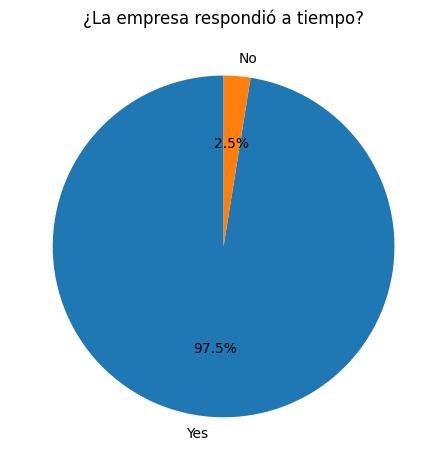

In [206]:
dt_quejas_corr['Timely response?'].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("¿La empresa respondió a tiempo?")
plt.ylabel("")
plt.tight_layout()
plt.show()

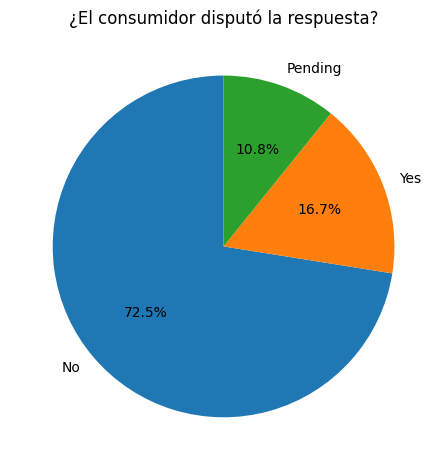

In [207]:
dt_quejas_corr['Consumer disputed?'].value_counts(normalize=True).plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("¿El consumidor disputó la respuesta?")
plt.ylabel("")
plt.tight_layout()
plt.show()

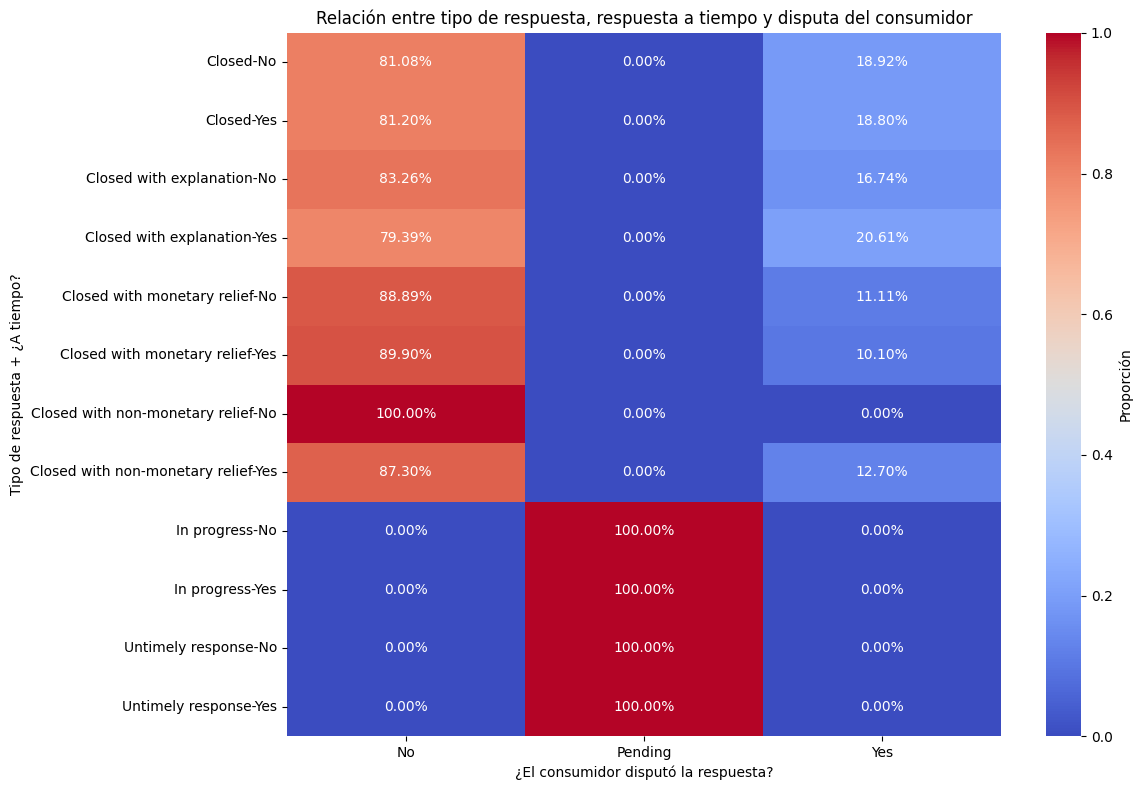

In [208]:
tabla_resumen = pd.crosstab(
    index=[dt_quejas_corr['Company response'], dt_quejas_corr['Timely response?']],
    columns=dt_quejas_corr['Consumer disputed?'],
    normalize='index'
)

# Configuración del gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_resumen, annot=True, fmt=".2%", cmap='coolwarm', cbar_kws={'label': 'Proporción'})
plt.title("Relación entre tipo de respuesta, respuesta a tiempo y disputa del consumidor")
plt.ylabel("Tipo de respuesta + ¿A tiempo?")
plt.xlabel("¿El consumidor disputó la respuesta?")
plt.tight_layout()
plt.show()

El análisis muestra que la gran mayoría de las empresas (97,5%) respondieron a las quejas dentro del plazo establecido, mientras que solo un 2,5% lo hicieron fuera de tiempo. Este elevado cumplimiento sugiere una posible influencia de normativas regulatorias o del interés de las compañías por preservar una buena reputación. Aun así, sería interesante explorar si las respuestas tardías se concentran en determinados productos o empresas.

Al observar la relación entre el tipo de respuesta, la puntualidad y la disputa del consumidor mediante el heatmap, se aprecia que las respuestas cerradas —ya sean con explicación o con algún tipo de alivio (monetario o no)— tienden a no ser disputadas. Por ejemplo, más del 80% de las respuestas en las categorías "Closed with explanation" o "Closed with monetary relief" no fueron cuestionadas por los consumidores. Esto sugiere que cuando las empresas brindan resoluciones más detalladas o beneficios tangibles, los clientes están más satisfechos.

Sin embargo, hay algunas excepciones. En los casos de "Closed with non-monetary relief", el nivel de disputa es más alto (~12,7%), lo que puede reflejar que los consumidores valoran más los beneficios económicos directos frente a otras formas de resolución. Además, observamos ciertas inconsistencias en las categorías "In progress" y "Untimely response", que aparecen vinculadas exclusivamente al estado “Pending” en la disputa, lo que podría indicar registros incompletos o errores de entrada en esos casos.

Por su parte, el gráfico de pastel sobre las disputas revela que el 72,5% de los consumidores no cuestionaron la respuesta recibida, mientras que el 16,7% sí lo hicieron y un 10,8% se mantiene en estado “Pending”. Esta variable ofrece información relevante sobre la percepción de los usuarios respecto a la eficacia del servicio recibido, y puede ser útil como variable objetivo o explicativa en modelos de predicción del descontento del consumidor.

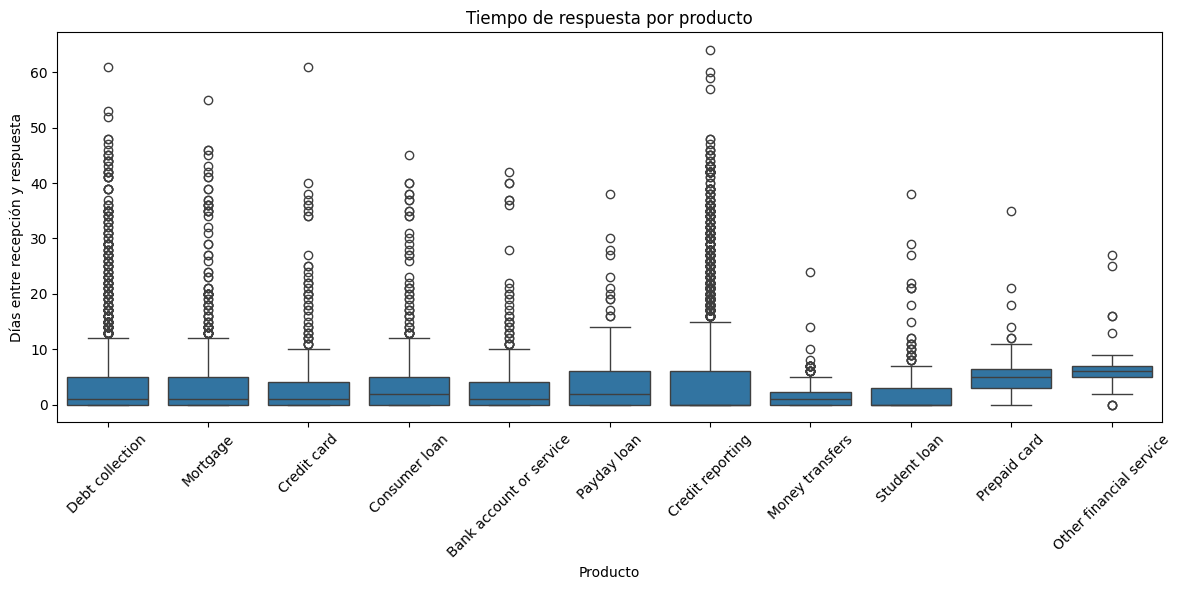

In [214]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=dt_quejas_corr, x='Product', y='Difference in days')
plt.xticks(rotation=45)
plt.title('Tiempo de respuesta por producto')
plt.ylabel('Días entre recepción y respuesta')
plt.xlabel('Producto')
plt.tight_layout()
plt.show()

Si observamos el tiempo de respuesta por parte de las empresas, desglosado por tipo de producto financiero. A primera vista, se observa que la mayoría de los productos presentan una mediana de respuesta muy baja (alrededor de 1 día), lo cual refuerza la idea de una atención rápida en la mayoría de casos. Sin embargo, la presencia de numerosos valores atípicos indica que existen situaciones puntuales con tiempos de respuesta mucho mayores.

Productos como Credit reporting, Payday loan o Debt collection destacan por tener una dispersión más alta y una mayor cantidad de outliers, lo cual podría deberse a la complejidad o conflictividad de estos servicios. Por el contrario, productos como Money transfers o Student loan presentan distribuciones más compactas, con menos casos extremos y tiempos de respuesta más consistentes.

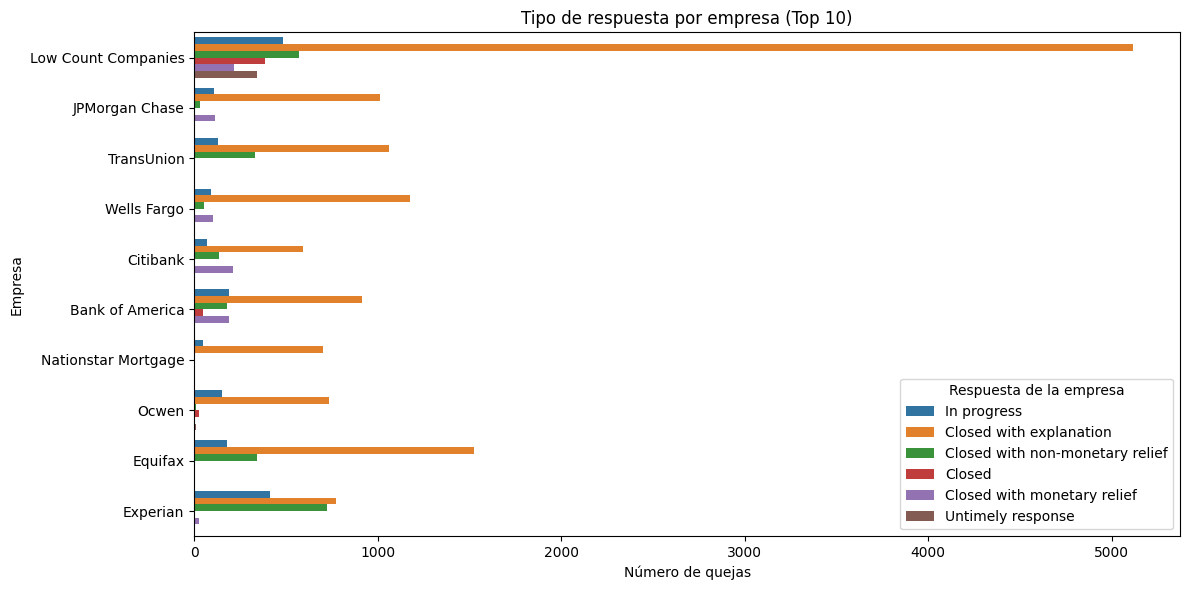

In [210]:
top_empresas = dt_quejas_corr['Company_grouped_filtered'].value_counts().nlargest(10).index
df_top_empresas = dt_quejas_corr[dt_quejas_corr['Company_grouped_filtered'].isin(top_empresas)]

plt.figure(figsize=(12,6))
sns.countplot(data=df_top_empresas, y='Company_grouped_filtered', hue='Company response')
plt.title('Tipo de respuesta por empresa (Top 10)')
plt.xlabel('Número de quejas')
plt.ylabel('Empresa')
plt.legend(title='Respuesta de la empresa')
plt.tight_layout()
plt.show()


Ahora centrandonos en el tipo de respuesta emitida por las diez empresas con mayor número de quejas. Lo primero que destaca es que la respuesta más habitual, con diferencia, es “Closed with explanation”, lo que sugiere que muchas compañías optan por cerrar los casos ofreciendo una explicación formal, sin ofrecer necesariamente compensaciones adicionales.

En empresas como Equifax, Wells Fargo o Bank of America, esta categoría domina claramente el conjunto de respuestas, lo cual puede indicar una política interna orientada a la resolución formal de conflictos sin implicar medidas compensatorias. Por otro lado, en Experian y TransUnion también se observa una presencia significativa de respuestas tipo “Closed with non-monetary relief”, lo que podría reflejar intentos de ofrecer otro tipo de soluciones, como correcciones en informes crediticios o gestiones administrativas.

Además, algunas compañías como Ocwen o Experian muestran una mayor proporción relativa de respuestas en estado “In progress” o incluso “Untimely response”, lo que podría apuntar a procesos internos más lentos o a una carga operativa elevada. Para la categoria "Low Count Companies" también domina el tipo de respuesta “Closed with explanation”, lo cual podría indicar que, independientemente del tamaño o la notoriedad de la empresa, existe una tendencia generalizada a cerrar las quejas mediante explicaciones formales. Sin embargo, esto también puede ocultar diferencias importantes entre las compañías que lo componen, ya que al estar agrupadas, perdemos visibilidad sobre sus comportamientos individuales.

In [211]:
ruta = r"C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Proyecto Fin de Modulo ML\data"
os.makedirs(ruta, exist_ok=True)

dt_quejas_corr.to_csv(os.path.join(ruta, "dt_quejas_corr.csv"), index=False)
